# Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import helper module
# import sys
# sys.path.insert(0, '..')
# from src.helpers import *

df = pd.read_csv("../data/naloxone_clean.csv") # main dataset

wards = pd.read_csv("../data/ward_demographics.csv") # supplementary dataset

## Q1. How have naloxone incidents evolved over the years?
This chart shows the total number of incidents registered and the total number of naloxone doses administered for each year from 2008-2025 (2007 and 2026 excluded because of partial data, making the chart misleading).

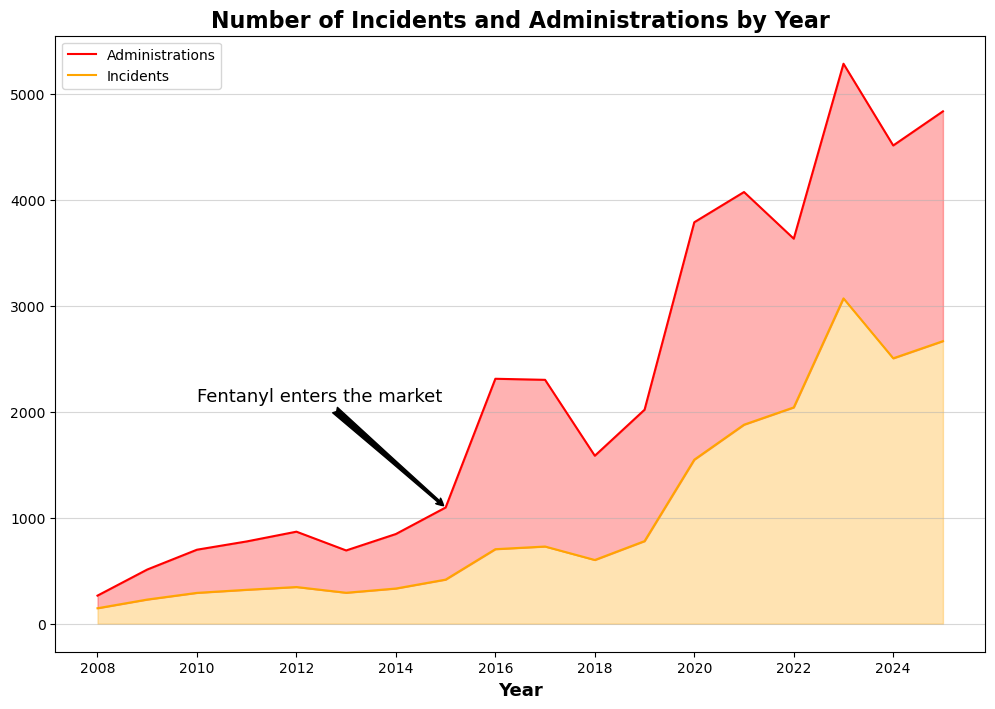

In [2]:
# preparing the data to plot
by_year = df.groupby("year")
administrations_year = by_year["naloxone_administrations"].sum().loc[2008:2025]
incidents_year = by_year["incident_number"].nunique().loc[2008:2025]

# plotting
fig, ax = plt.subplots(figsize=(12, 8))

# plot both lines
ax.plot(administrations_year.index, administrations_year, color="red", label="Administrations")
ax.plot(incidents_year.index, incidents_year, color="orange", label="Incidents")

# fill both areas
ax.fill_between(incidents_year.index, incidents_year, color="orange", alpha=0.3)
ax.fill_between(administrations_year.index, incidents_year, administrations_year, color="red", alpha=0.3)

# text + arrow annotation about fentanyl
ax.annotate("Fentanyl enters the market",
            xy=(2015, administrations_year[2015]),
            xytext=(2015 - 5, administrations_year[2015] + 1000),
            arrowprops=dict(arrowstyle="fancy", color="black"),
            fontsize=13)


ax.set_xticks([2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024])

# labeling the plot
ax.set_title("Number of Incidents and Administrations by Year", fontsize=16, fontweight="bold")
ax.set_xlabel("Year", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.5)

# displaying the chart
ax.legend()
plt.show()

Incidents have grown steadily since 2008, with a sharp spike in 2015 to 2018. The year of 2015 was the arrival of fentanyl to the Winnipeg's drug market, which explains why administrations spiked much faster than incidents during that time: the same number of patients started requiring more doses to reverse overdoses. The gap between the two lines is a measure of how much more dangerous drugs became over time.

## Q2. Are there temporal patterns in when incidents occur?
This chart breaks down incidents by day of the week and by hour of the day, to see if overdoses cluster at specific times.

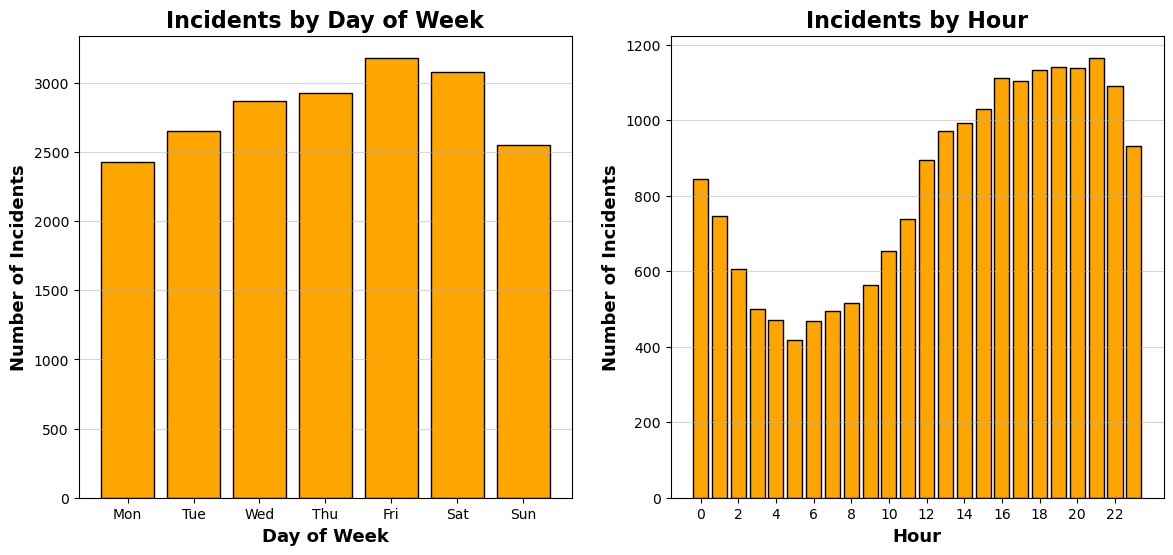

In [3]:
# preparing the data
incidents_dow = df.groupby("day_of_week")["incident_number"].nunique()
incidents_hour = df.groupby("hour")["incident_number"].nunique()

# plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# plotting left bar chart (incidents by day of week)
ax[0].bar(incidents_dow.index, incidents_dow, color="orange", edgecolor="black")
ax[0].set_xticks(np.arange(0, 7))

# labeling left bar chart
ax[0].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax[0].set_title("Incidents by Day of Week", fontsize=16, fontweight="bold")
ax[0].set_xlabel("Day of Week", fontsize=13, fontweight="bold")
ax[0].set_ylabel("Number of Incidents", fontsize=13, fontweight="bold")

# plotting right bar chart (incidents by hour)
ax[1].bar(incidents_hour.index, incidents_hour, color="orange", edgecolor="black", width=0.8)
ax[1].set_xticks(np.arange(0, 24, 2))

# labeling right bar chart
ax[1].set_title("Incidents by Hour", fontsize=16, fontweight="bold")
ax[1].set_xlabel("Hour", fontsize=13, fontweight="bold")
ax[1].set_ylabel("Number of Incidents", fontsize=13, fontweight="bold")

# setting the grid for both charts
ax[0].grid(axis="y", alpha=0.5)
ax[1].grid(axis="y", alpha=0.5)

# displaying the figure
plt.show()

Incidents are relatively consistent across all days of the week, with a slight peak on Fridays and Saturdays. The hour chart tells a clearer story: incident volume appears to follow daily activity cycles, with a low point at 5am and a gradual buildup throughout the day, peaking at 8pm before declining through the night.